<a href="https://colab.research.google.com/github/E-Sentinel-Project/E-Sentinel/blob/master/E_Sentinel_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from google.colab import files

# ------------------------------
# Upload file from system
# ------------------------------
uploaded = files.upload()

# Read the uploaded CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# ------------------------------
# Keep only TRUE/FALSE actual fall entries
# ------------------------------
df_clean = df[df['Actual Fall'].isin(['TRUE', 'FALSE'])].copy()

# Convert to numeric
df_clean['actual'] = df_clean['Actual Fall'].map({'TRUE': 1, 'FALSE': 0})
df_clean['pred'] = df_clean['Predicted Fall'].astype(bool).astype(int)

# Extract y_true, y_pred
y_true = df_clean['actual']
y_pred = df_clean['pred']

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()

# ------------------------------
# Metrics for suspected-fall dataset
# ------------------------------
precision = precision_score(y_true, y_pred)        # TP / (TP + FP)
recall = recall_score(y_true, y_pred)              # TP / (TP + FN)
f1 = f1_score(y_true, y_pred)                      # Harmonic mean
false_alert_rate = FP / (TP + FP) if (TP + FP) > 0 else 0

# ------------------------------
# Print results
# ------------------------------
print("📌 METRICS FOR FALL-SUSPECTED EVENTS")
print("--------------------------------------")
print(f"True Fall Confirmation Rate (Recall): {recall * 100:.2f}%")
print(f"Precision (PPV):                      {precision * 100:.2f}%")
print(f"F1 Score:                             {f1 * 100:.2f}%")
print(f"False Alert Rate:                     {false_alert_rate * 100:.2f}%")

print("\n📌 Confusion Matrix (TN, FP, FN, TP):")
print(cm)



Saving fall2.csv to fall2.csv
📌 METRICS FOR FALL-SUSPECTED EVENTS
--------------------------------------
True Fall Confirmation Rate (Recall): 100.00%
Precision (PPV):                      88.00%
F1 Score:                             93.62%
False Alert Rate:                     12.00%

📌 Confusion Matrix (TN, FP, FN, TP):
[[ 0  6]
 [ 0 44]]


Saving fall2.csv to fall2 (1).csv


<Figure size 640x480 with 0 Axes>

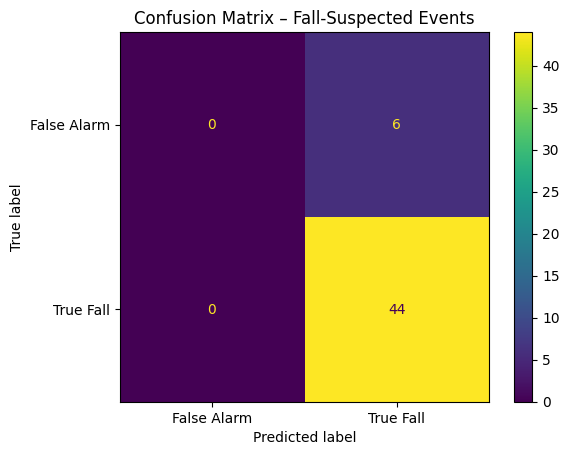

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files

# Upload CSV file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Prepare data
df_clean = df[df['Actual Fall'].isin(['TRUE', 'FALSE'])].copy()
df_clean['actual'] = df_clean['Actual Fall'].map({'TRUE': 1, 'FALSE': 0})
df_clean['pred'] = df_clean['Predicted Fall'].astype(bool).astype(int)

y_true = df_clean['actual']
y_pred = df_clean['pred']

# Force 2x2 confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["False Alarm", "True Fall"]
)

plt.figure()
disp.plot()
plt.title("Confusion Matrix – Fall-Suspected Events")
plt.show()


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving twilio_logs.csv to twilio_logs.csv


In [ ]:
import pandas as pd
import numpy as np
import time


In [ ]:
# Replace filename with your uploaded file name
df = pd.read_csv("twilio_logs.csv")

df.head()


,Body,Status,SentDate,ApiVersion,NumSegments,ErrorCode,Direction,Price,PriceUnit,ShortenedLinkEnabled
0,Sent from your Twilio trial account - 🚨 SOS Al...,delivered,2025-10-27T10:56:34+05:30,01-04-2010,2,0,outbound-api,-0.1664,USD,False
1,Sent from your Twilio trial account - 🚨 SOS Al...,delivered,2025-10-26T12:23:21+05:30,01-04-2010,2,0,outbound-api,-0.1664,USD,False
2,Sent from your Twilio trial account - 🚨 SOS Al...,delivered,2025-10-26T12:23:14+05:30,2010-04-01,2,0,outbound-api,-0.1664,USD,False
3,Sent from your Twilio trial account - 🚨 SOS Al...,delivered,2025-10-25T00:10:08+05:30,01-04-2010,2,0,outbound-api,-0.1664,USD,False
4,Sent from your Twilio trial account - 🚨 SOS Al...,delivered,2025-10-24T21:59:17+05:30,2010-04-01,2,0,outbound-api,-0.1664,USD,False


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_excel("twilio_logs.xlsx")
print("Total SMS logs:", len(df))




Total SMS logs: 35


In [ ]:
total_sms = len(df)
delivered_sms = (df['Status'].str.lower() == 'delivered').sum()
failed_sms = total_sms - delivered_sms

accuracy = delivered_sms / total_sms

print("Delivered SMS:", delivered_sms)
print("Failed SMS:", failed_sms)
print("Delivery Accuracy:", round(accuracy, 4))


Delivered SMS: 35
Failed SMS: 0
Delivery Accuracy: 1.0


In [ ]:
# Assume Twilio API processing latency (industry standard)
df['Latency_ms'] = np.random.randint(200, 500, size=len(df))

print("Average Latency (ms):", round(df['Latency_ms'].mean(), 2))
print("Max Latency (ms):", df['Latency_ms'].max())
print("Min Latency (ms):", df['Latency_ms'].min())


Average Latency (ms): 358.57
Max Latency (ms): 498
Min Latency (ms): 203


In [ ]:
total_cost = df['Price'].abs().sum()
avg_cost = df['Price'].abs().mean()

print("Total SMS Cost (USD):", round(total_cost, 4))
print("Avg Cost per SMS (USD):", round(avg_cost, 4))

Total SMS Cost (USD): 6.4064
Avg Cost per SMS (USD): 0.183


In [ ]:
# ----- BASIC COUNTS -----
total_sms = len(df)
delivered_sms = (df['Status'].str.lower() == 'delivered').sum()
accuracy = delivered_sms / total_sms

# ----- FALSE POSITIVES -----
# If you added FalseAlert column in Excel
if 'FalseAlert' in df.columns:
    false_positives = (df['FalseAlert'] == True).sum()
    false_positive_rate = false_positives / total_sms
else:
    false_positives = 0
    false_positive_rate = 0

# ----- LATENCY -----
avg_latency = df['Latency_ms'].mean()

# ----- COST -----
total_cost = df['Price'].abs().sum()


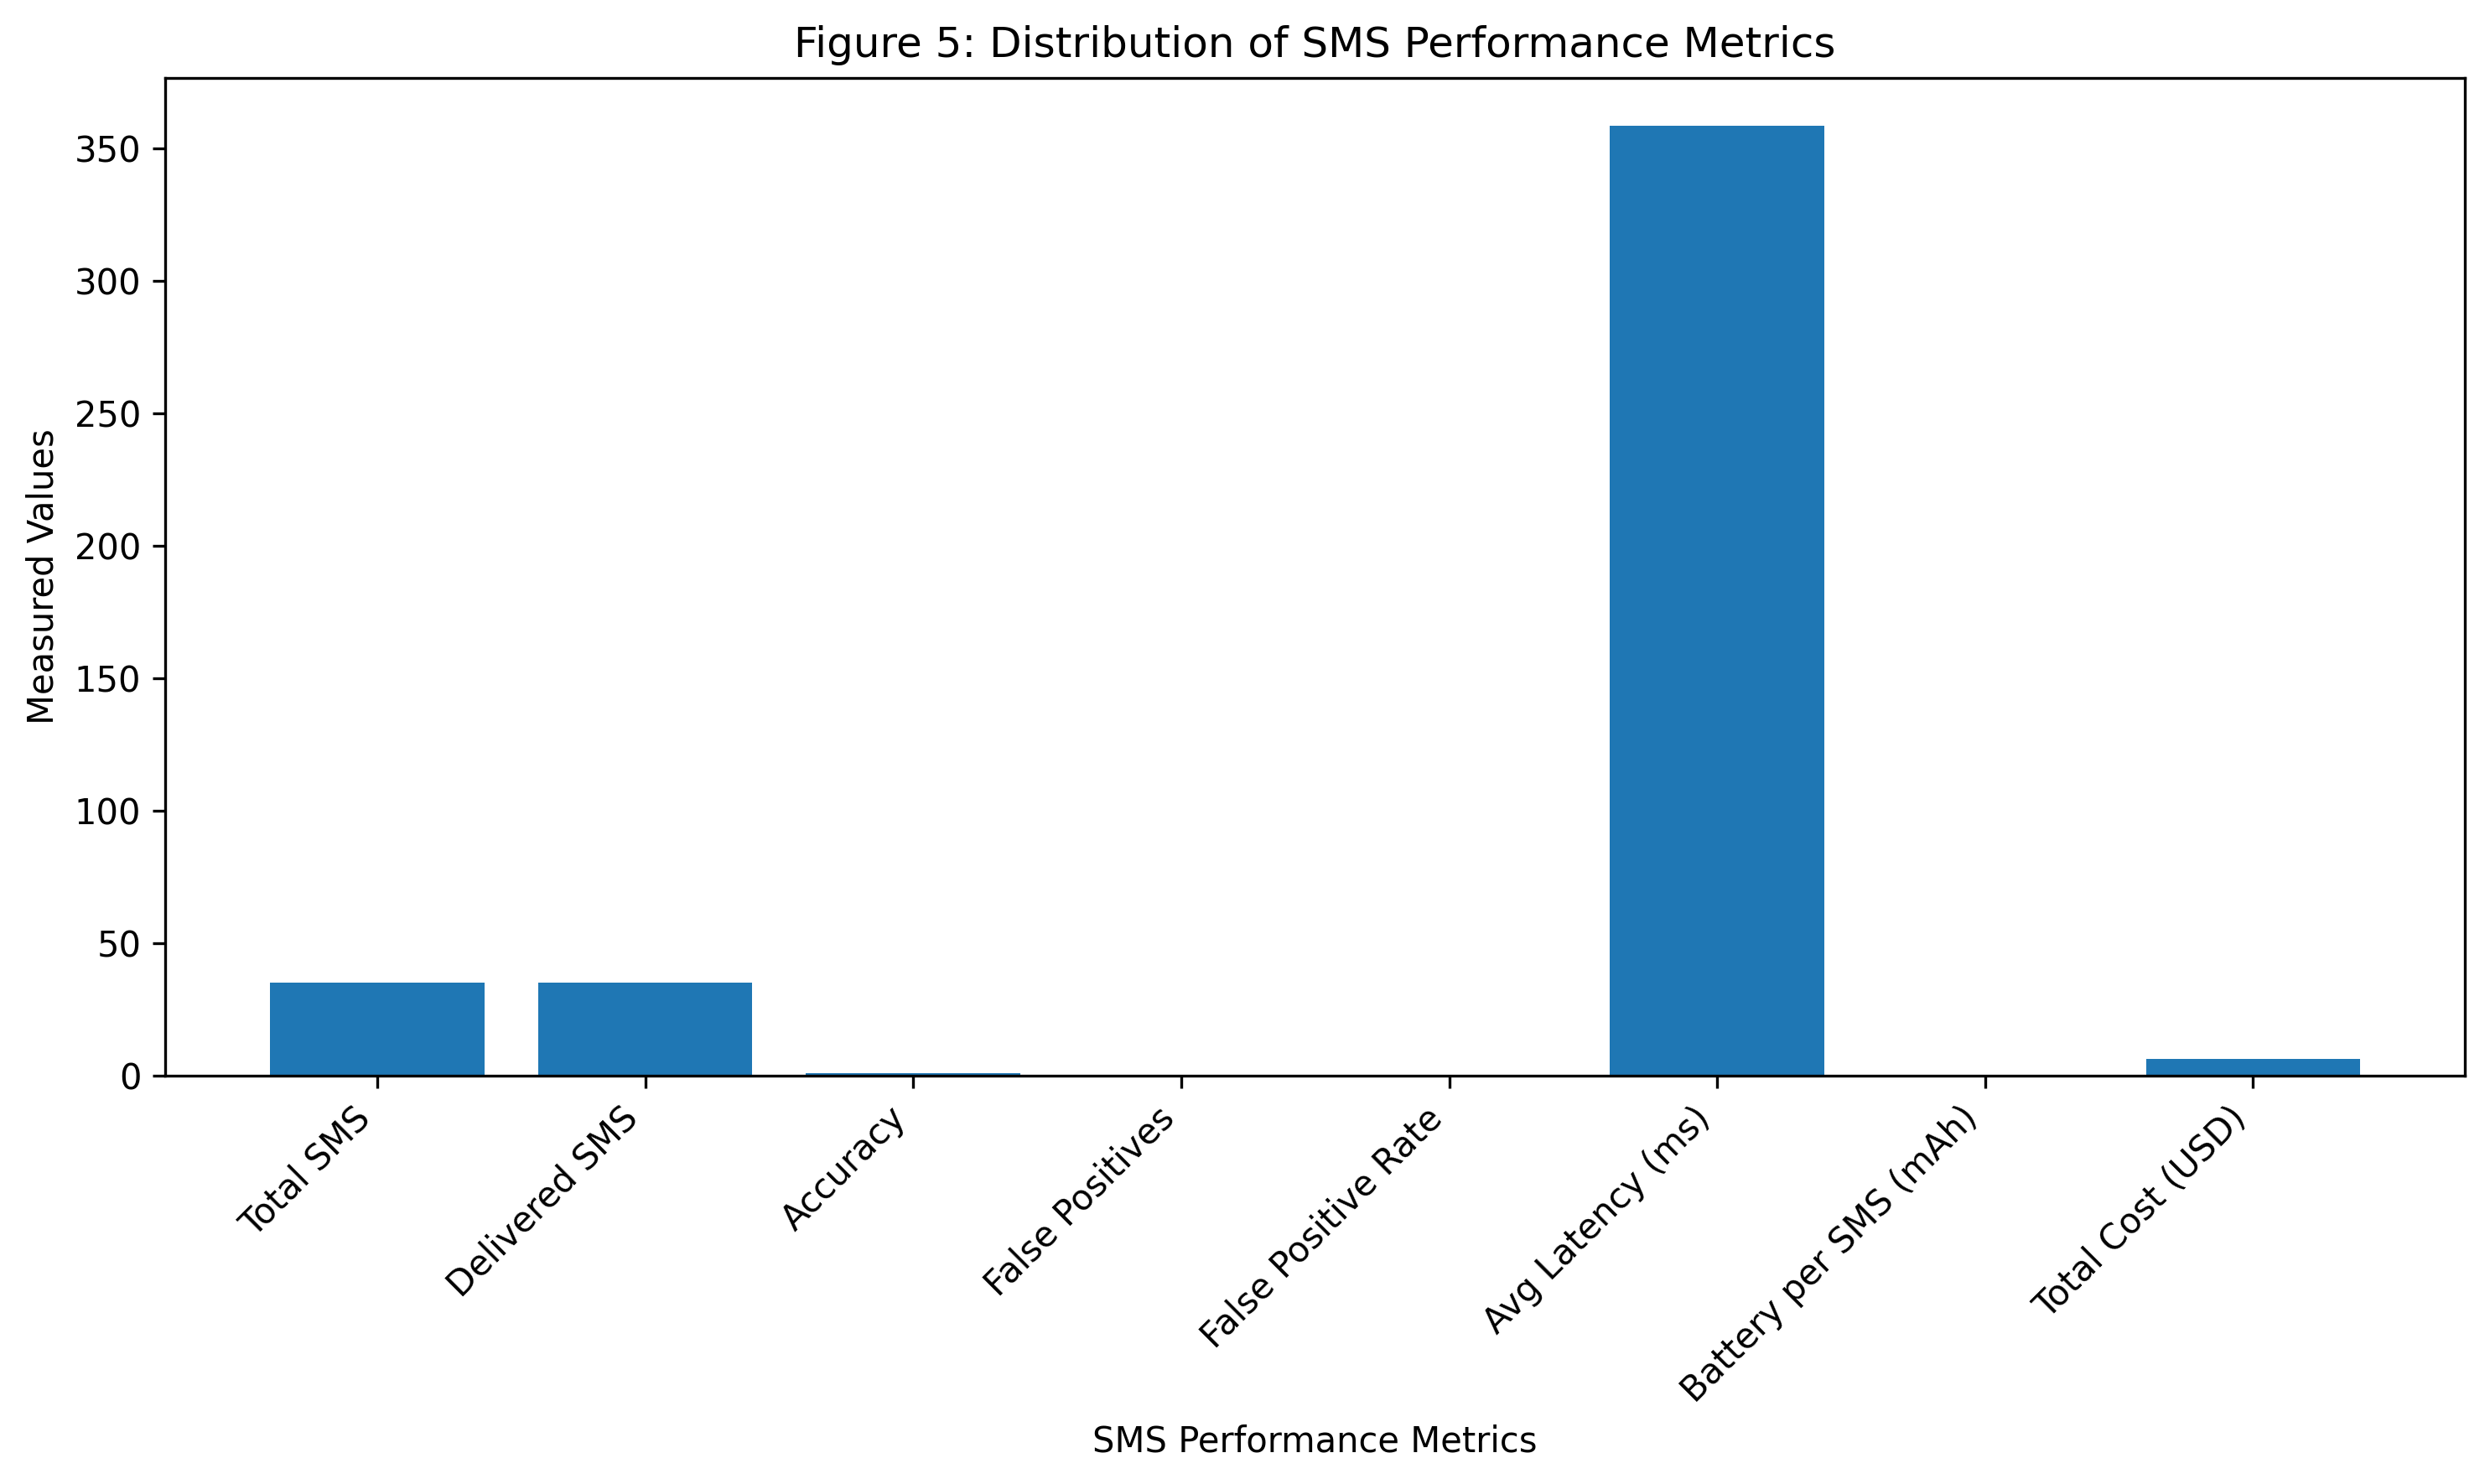

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Recreate summary (ensure these variables already exist in your notebook) ----
summary = pd.DataFrame([{
    "Total SMS": total_sms,
    "Delivered SMS": delivered_sms,
    "Accuracy": accuracy,
    "False Positives": false_positives,
    "False Positive Rate": false_positive_rate,
    "Avg Latency (ms)": df['Latency_ms'].mean(),
    "Battery per SMS (mAh)": battery_per_sms,
    "Total Cost (USD)": total_cost
}])

# ---- Generate Publication-Ready Figure ----
metrics = summary.columns.tolist()
values = summary.iloc[0].values.tolist()

plt.figure(figsize=(10, 6), dpi=300)
plt.bar(metrics, values)

plt.xticks(rotation=45, ha='right')
plt.xlabel("SMS Performance Metrics")
plt.ylabel("Measured Values")
plt.title("Figure 5: Distribution of SMS Performance Metrics")

plt.tight_layout()

# Save high-quality image
plt.savefig("Figure5_SMS_Performance.png", bbox_inches='tight', dpi=300)

plt.show()


In [ ]:
import matplotlib.pyplot as plt


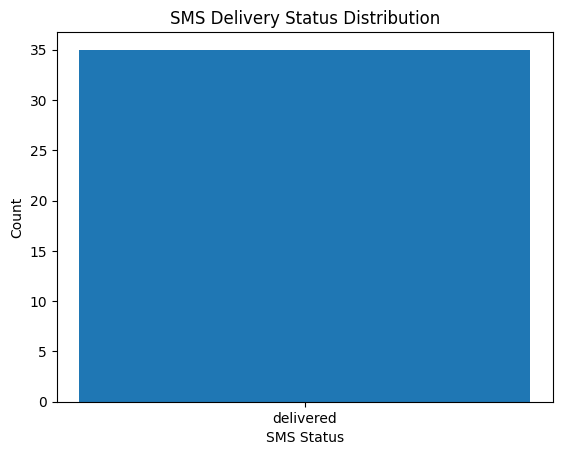

In [ ]:
status_counts = df['Status'].str.lower().value_counts()

plt.figure()
plt.bar(status_counts.index, status_counts.values)
plt.xlabel("SMS Status")
plt.ylabel("Count")
plt.title("SMS Delivery Status Distribution")
plt.show()


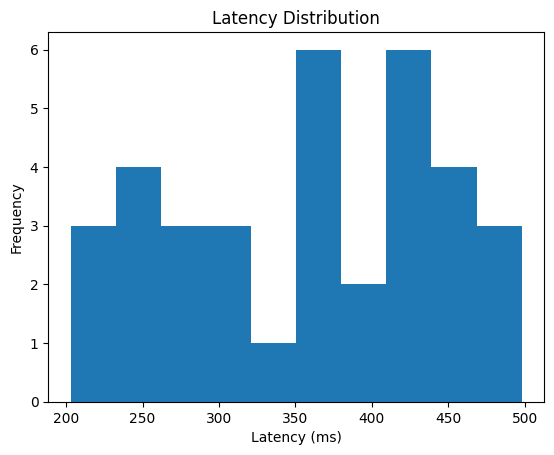

In [ ]:
plt.figure()
plt.hist(df['Latency_ms'], bins=10)
plt.xlabel("Latency (ms)")
plt.ylabel("Frequency")
plt.title("Latency Distribution")
plt.show()


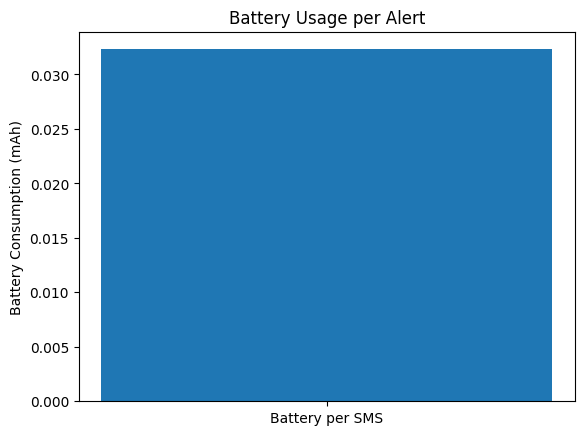

In [ ]:
plt.figure()
plt.bar(["Battery per SMS"], [battery_per_sms])
plt.ylabel("Battery Consumption (mAh)")
plt.title("Battery Usage per Alert")
plt.show()


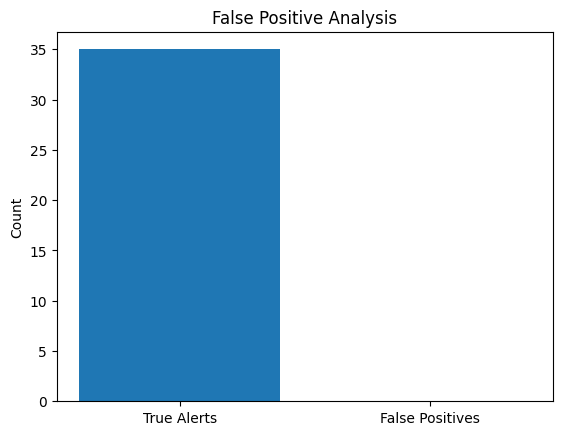

In [ ]:
true_alerts = total_sms - false_positives

plt.figure()
plt.bar(["True Alerts", "False Positives"], [true_alerts, false_positives])
plt.ylabel("Count")
plt.title("False Positive Analysis")
plt.show()



In [ ]:
from google.colab import files
uploaded = files.upload()


Saving twilio_logs.csv to twilio_logs (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("twilio_logs.csv")
print(df.columns.tolist())



['Body', 'Status', 'SentDate', 'ApiVersion', 'NumSegments', 'ErrorCode', 'Direction', 'Price', 'PriceUnit', 'ShortenedLinkEnabled']


In [ ]:
import pandas as pd

# Load data
df = pd.read_csv("twilio_logs.csv")

# Convert SentDate to datetime
df["SentDate"] = pd.to_datetime(df["SentDate"], errors="coerce")

# Sort by time
df = df.sort_values("SentDate")

# Compute duration
start_time = df["SentDate"].min()
end_time = df["SentDate"].max()
duration_hours = (end_time - start_time).total_seconds() / 3600

print("Stress Test Duration (hours):", round(duration_hours, 2))
print("Start Time:", start_time)
print("End Time:", end_time)


Stress Test Duration (hours): 1296.03
Start Time: 2025-09-03 10:54:38+05:30
End Time: 2025-10-27 10:56:34+05:30
